# Machine Learning For Events Data

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json, pickle, os
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, ConfusionMatrixDisplay

Pramettrage des Couleurs 

In [2]:
COLORS = {'primary':'#E91E8C','secondary':'#7B2FBE','accent':'#00D4AA','dark':'#1A1A2E'}
PALETTE= ['#E91E8C','#7B2FBE','#00D4AA','#FF6B35','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.25,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})

BASE      = Path('..')
DATA_PROC = BASE / 'data' / 'processed'
MODELS    = BASE / 'models'
for p in [DATA_PROC, MODELS, BASE/'data'/'raw']: p.mkdir(parents=True, exist_ok=True)

In [26]:
# Importation
df = pd.read_parquet('../data/raw/eventsBeninonly.parquet')

df.sample(5)

,SQLDATE,Year,MonthYear,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,Actor2Type1Code,EventCode,...,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_CountryCode,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
1728,20260427,2026,202604,TOGO,TGO,None,BENIN,BEN,None,051,...,3.4,1,1,1,3.358779,BN,Benin,9.50000,2.25000,https://www.prurgent.com/2026-04-26/pressrelea...
1644,20250525,2025,202505,AFRICA,AFR,None,None,None,None,120,...,-4.0,10,1,10,1.523229,BN,Benin,9.50000,2.25000,https://www.eldiario.es/canariasahora/sociedad...
2087,20250129,2025,202501,BRAZILIAN,BRA,None,AFRICA,AFR,None,042,...,1.9,2,1,2,-0.937500,BN,"Ouidah, Atlantique, Benin",6.36307,2.08506,https://www.aol.co.uk/news/africa-where-m-why-...
2912,20250610,2025,202506,STATE COLLEGE,USA,None,HOUSE OF ASSEMBLY,None,LEG,042,...,1.9,5,1,5,3.825137,BN,Benin,9.50000,2.25000,https://thesun.ng/okpebholo-builds-sub-injecti...
4187,20260420,2026,202604,AFRICA,AFR,None,BENIN,BEN,None,051,...,3.4,2,1,2,-4.187605,BN,Benin,9.50000,2.25000,https://lesoleil.sn/international/infos-afriqu...


In [32]:
cameo_event_code = pd.read_csv('../data/raw/CAMEOeventcodesFR.txt', sep='\t', dtype=str , encoding="cp1252")
cameo = cameo_event_code.set_index("CAMEOEVENTCODE")["DESCRIPTION DE L’ÉVÉNEMENT"].to_dict()
df["EventName"] = df["EventRootCode"].map(cameo).fillna("Other")

In [39]:
df['EventCode']

0       051
1       051
2       051
3       010
4       010
       ... 
4711    043
4712    043
4713    013
4714    051
4715    042
Name: EventCode, Length: 4716, dtype: object

In [34]:

qmap={1:'Coopération verbale',2:'Coopération matérielle',3:'Conflit verbal',4:'Conflit matériel'}
df['EventLabel']=df['EventCode'].map(cameo).fillna('Autre')
df['QuadLabel']=df['QuadClass'].map(qmap)
df['CameoTheme']=df['EventRootCode'].map(cameo).fillna('Autre')

df['MediaWeight']  = df['NumMentions'] * df['NumArticles']
df['IsConflict']   = (df['QuadClass'] >= 3).astype(int)
df['IsNegative']   = (df['AvgTone'] < 0).astype(int)
df['ToneCategory'] = pd.cut(df['AvgTone'],bins=[-100,-5,-1,1,5,100],
                     labels=['Très négatif','Négatif','Neutre','Positif','Très positif'])

df["date"] = pd.to_datetime(df['SQLDATE'], errors='coerce')

df = df.dropna(subset=['date'])
# df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_label'] = df['date'].dt.strftime('%b %Y')
df['quarter']     = df['date'].dt.quarter

for c in ['GoldsteinScale','AvgTone','NumMentions','NumSources','NumArticles']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median())

df['SourceDomain'] = df['SOURCEURL'].str.extract(r'https?://(?:www\.)?([^/]+)')
df['SourceRegion'] = df['SourceDomain'].apply(
    lambda x: 'Afrique' if any(d in str(x) for d in ['bj','afrik','allafrica','apanews','voa','beninweb'])
    else ('Occident' if any(d in str(x) for d in ['bbc','lemonde','reuters','rfi']) else 'Autre'))

In [ ]:
from pandasql import sqldf

# Fonction pour executer le code SQL
pysqldf = lambda q: sqldf(q, globals())

# SQL test Liste des mois disponibles
query = "SELECT  AS NB FROM df GROUP BY CameoTheme ORDER BY 2 DESC"
result = pysqldf(query)
result

,Evenement,NB
0,CONSULTER,1384
1,COOPÉRATION DIPLOMATIQUE,705
2,FAIRE UNE DÉCLARATION PUBLIQUE,450
3,DÉSAPPROUVER,282
4,COMBATTRE,267
5,APPEL,260
6,EXPRIMER L’INTENTION DE COOPÉRER,245
7,FOURNIR UNE AIDE,186
8,CÉDER,162
9,CONTRAINDRE,149


In [ ]:
df.to_csv("../data/processed/gdelt_benin_clean.csv")

Index(['SQLDATE', 'Year', 'MonthYear', 'Actor1Name', 'Actor1CountryCode',
       'Actor1Type1Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code',
       'EventCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale',
       'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'ActionGeo_CountryCode', 'ActionGeo_FullName', 'ActionGeo_Lat',
       'ActionGeo_Long', 'SOURCEURL', 'EventName', 'EventLabel', 'QuadLabel',
       'CameoTheme', 'MediaWeight', 'IsConflict', 'IsNegative', 'ToneCategory',
       'date', 'year', 'month', 'month_label', 'quarter', 'SourceDomain',
       'SourceRegion', 'Actor1Type_enc', 'CameoTheme_enc', 'Cluster', 'PCA1',
       'PCA2'],
      dtype='object')

In [47]:
le=LabelEncoder()
df['Actor1Type_enc']=le.fit_transform(df['Actor1Type1Code'].fillna('UNK'))
df['CameoTheme_enc']=le.fit_transform(df['CameoTheme'].fillna('Autre'))
FEAT=['GoldsteinScale','AvgTone','NumMentions','NumArticles','NumSources','MediaWeight','Actor1Type_enc','CameoTheme_enc']
X=df[FEAT].fillna(0); y=df['IsConflict']
scaler=StandardScaler(); X_sc=scaler.fit_transform(X)
print(f'✅ Features: {X.shape} | Conflits: {y.mean()*100:.1f}%')


✅ Features: (4716, 8) | Conflits: 24.6%


k=2: silhouette=0.2957
k=3: silhouette=0.2472
k=4: silhouette=0.2697
k=5: silhouette=0.2667
k=6: silhouette=0.2749
k=7: silhouette=0.2962
k=8: silhouette=0.3015
k=9: silhouette=0.3139

✅ k optimal = 9


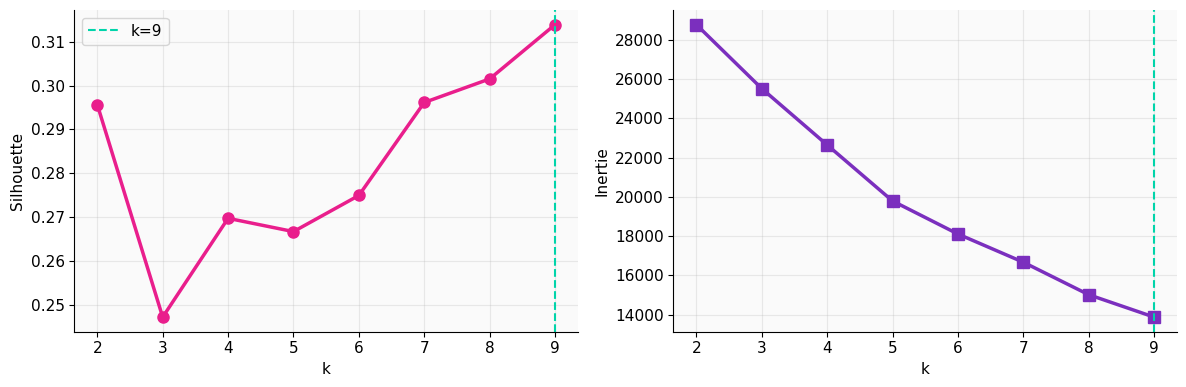

In [51]:
# K-Means optimal
sil,inert={},{}
for k in range(2,10):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    lbl=km.fit_predict(X_sc)
    sil[k]=silhouette_score(X_sc,lbl,sample_size=2000)
    inert[k]=km.inertia_
    print(f'k={k}: silhouette={sil[k]:.4f}')
best_k=max(sil,key=sil.get)
print(f'\n✅ k optimal = {best_k}')

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(list(sil.keys()),list(sil.values()),'o-',color=COLORS['primary'],lw=2.5,ms=8)
axes[0].axvline(best_k,ls='--',color=COLORS['accent'],label=f'k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette'); axes[0].legend()
axes[1].plot(list(inert.keys()),list(inert.values()),'s-',color=COLORS['secondary'],lw=2.5,ms=8)
axes[1].axvline(best_k,ls='--',color=COLORS['accent'])
axes[1].set_xlabel('k'); axes[1].set_ylabel('Inertie')
plt.tight_layout(); plt.show()

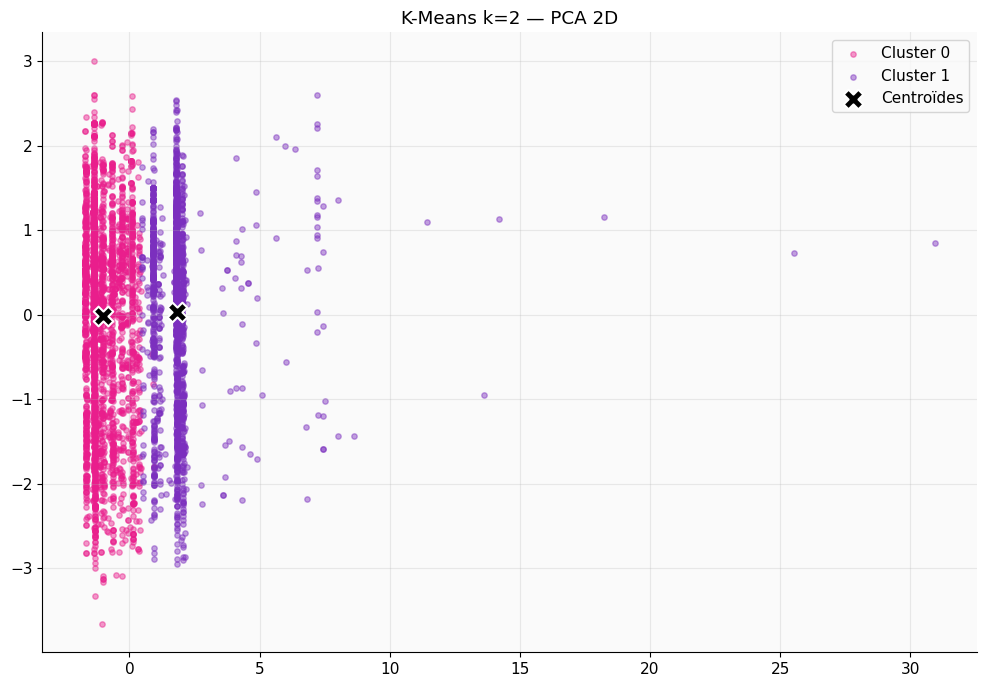

         Événements  Tone_moyen  Goldstein_moy  Thème_top Ville_top Conflits_pct
Cluster                                                                         
0              3045       -0.93           1.14  CONSULTER     Benin          24%
1              1671       -0.76           0.93  CONSULTER     Benin          25%


In [52]:
# K-Means final + PCA
kmeans=KMeans(n_clusters=2,random_state=42,n_init=10)
df['Cluster']=kmeans.fit_predict(X_sc)
pca=PCA(n_components=2,random_state=42)
Xpca=pca.fit_transform(X_sc)
df['PCA1'],df['PCA2']=Xpca[:,0],Xpca[:,1]

fig,ax=plt.subplots(figsize=(10,7))
for i,c in enumerate(sorted(df['Cluster'].unique())):
    mask=df['Cluster']==c
    ax.scatter(df.loc[mask,'PCA1'],df.loc[mask,'PCA2'],s=15,alpha=.45,color=PALETTE[i],label=f'Cluster {c}')
centers_2d=pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:,0],centers_2d[:,1],s=200,marker='X',color='black',edgecolors='white',lw=1.5,zorder=5,label='Centroïdes')
ax.set_title(f'K-Means k={2} — PCA 2D'); ax.legend()
plt.tight_layout(); plt.savefig(DATA_PROC/'viz_clusters.png',dpi=150,bbox_inches='tight'); plt.show()

profile=df.groupby('Cluster').agg(
    Événements=('EventCode','count'),Tone_moyen=('AvgTone','mean'),
    Goldstein_moy=('GoldsteinScale','mean'),Thème_top=('CameoTheme',lambda x:x.mode()[0]),
    Ville_top=('ActionGeo_FullName',lambda x:x.mode()[0]),
    Conflits_pct=('IsConflict',lambda x:f'{x.mean()*100:.0f}%')).round(2)
print(profile.to_string())

              precision    recall  f1-score   support

 Coopération       1.00      0.99      0.99       711
     Conflit       0.97      1.00      0.98       233

    accuracy                           0.99       944
   macro avg       0.98      0.99      0.99       944
weighted avg       0.99      0.99      0.99       944



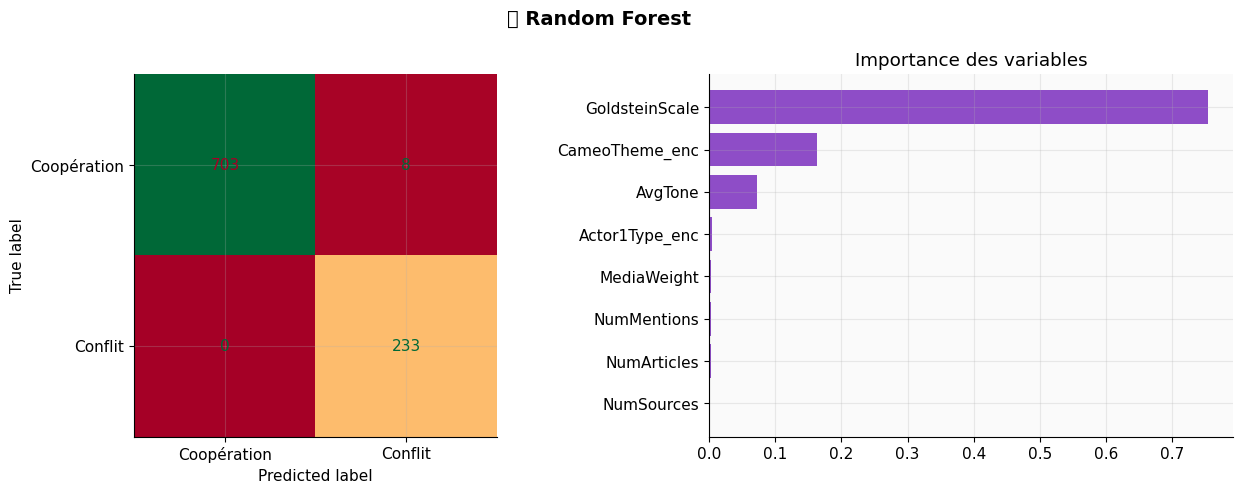

In [53]:
# Random Forest
Xtr,Xte,ytr,yte=train_test_split(X_sc,y,test_size=0.2,random_state=42,stratify=y)
rf=RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_leaf=5,
                           random_state=42,n_jobs=-1,class_weight='balanced')
rf.fit(Xtr,ytr); y_pred=rf.predict(Xte)
report=classification_report(yte,y_pred,target_names=['Coopération','Conflit'],output_dict=True)
cm=confusion_matrix(yte,y_pred)
print(classification_report(yte,y_pred,target_names=['Coopération','Conflit']))

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('🌲 Random Forest',fontsize=14,fontweight='bold')
ConfusionMatrixDisplay(cm,display_labels=['Coopération','Conflit']).plot(ax=axes[0],cmap='RdYlGn',colorbar=False)
imp=pd.Series(rf.feature_importances_,index=FEAT).sort_values()
axes[1].barh(imp.index,imp.values,color=COLORS['secondary'],alpha=.85)
axes[1].set_title('Importance des variables')
plt.tight_layout(); plt.savefig(DATA_PROC/'viz_rf.png',dpi=150,bbox_inches='tight'); plt.show()